In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pylab
import scipy.stats as stat
from scipy.stats import ttest_ind, chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols
from category_encoders import TargetEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
import os

In [31]:
os.chdir ("C:\\Academic Projects\\DIABETES-DETECTION\\")
df = pd.read_csv("Diabetes-dataset_FS_enhanced.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI,...,Glucose.1,BMI.1,Age.1,Insulin.1,Glucose BMI,Glucose Age,Glucose Insulin,BMI Age,BMI Insulin,Age Insulin
0,6,148.0,72.0,35.0,125.0,33.6,0.62700,50,1,4972.8,...,148.0,33.6,50.0,125.0,4972.8,7400.0,18500.0,1680.0,4200.0,6250.0
1,1,85.0,66.0,29.0,125.0,26.6,0.35100,31,0,2261.0,...,85.0,26.6,31.0,125.0,2261.0,2635.0,10625.0,824.6,3325.0,3875.0
2,8,183.0,64.0,29.0,125.0,23.3,0.67200,32,1,4263.9,...,183.0,23.3,32.0,125.0,4263.9,5856.0,22875.0,745.6,2912.5,4000.0
3,1,89.0,66.0,23.0,94.0,28.1,0.16700,21,0,2500.9,...,89.0,28.1,21.0,94.0,2500.9,1869.0,8366.0,590.1,2641.4,1974.0
4,0,137.0,44.0,35.0,168.0,43.1,1.69833,33,1,5904.7,...,137.0,43.1,33.0,168.0,5904.7,4521.0,23016.0,1422.3,7240.8,5544.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.17100,63,0,3322.9,...,101.0,32.9,63.0,180.0,3322.9,6363.0,18180.0,2072.7,5922.0,11340.0
764,2,122.0,70.0,27.0,125.0,36.8,0.34000,27,0,4489.6,...,122.0,36.8,27.0,125.0,4489.6,3294.0,15250.0,993.6,4600.0,3375.0
765,5,121.0,72.0,23.0,112.0,26.2,0.24500,30,0,3170.2,...,121.0,26.2,30.0,112.0,3170.2,3630.0,13552.0,786.0,2934.4,3360.0
766,1,126.0,60.0,29.0,125.0,30.1,0.34900,47,1,3792.6,...,126.0,30.1,47.0,125.0,3792.6,5922.0,15750.0,1414.7,3762.5,5875.0


Spliting dependent and independent variable

In [32]:
df_X = df.drop('Outcome', axis=1)
df_X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI,Insulin_Glucose,...,Glucose.1,BMI.1,Age.1,Insulin.1,Glucose BMI,Glucose Age,Glucose Insulin,BMI Age,BMI Insulin,Age Insulin
0,6,148.0,72.0,35.0,125.0,33.6,0.62700,50,4972.8,18500.0,...,148.0,33.6,50.0,125.0,4972.8,7400.0,18500.0,1680.0,4200.0,6250.0
1,1,85.0,66.0,29.0,125.0,26.6,0.35100,31,2261.0,10625.0,...,85.0,26.6,31.0,125.0,2261.0,2635.0,10625.0,824.6,3325.0,3875.0
2,8,183.0,64.0,29.0,125.0,23.3,0.67200,32,4263.9,22875.0,...,183.0,23.3,32.0,125.0,4263.9,5856.0,22875.0,745.6,2912.5,4000.0
3,1,89.0,66.0,23.0,94.0,28.1,0.16700,21,2500.9,8366.0,...,89.0,28.1,21.0,94.0,2500.9,1869.0,8366.0,590.1,2641.4,1974.0
4,0,137.0,44.0,35.0,168.0,43.1,1.69833,33,5904.7,23016.0,...,137.0,43.1,33.0,168.0,5904.7,4521.0,23016.0,1422.3,7240.8,5544.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.17100,63,3322.9,18180.0,...,101.0,32.9,63.0,180.0,3322.9,6363.0,18180.0,2072.7,5922.0,11340.0
764,2,122.0,70.0,27.0,125.0,36.8,0.34000,27,4489.6,15250.0,...,122.0,36.8,27.0,125.0,4489.6,3294.0,15250.0,993.6,4600.0,3375.0
765,5,121.0,72.0,23.0,112.0,26.2,0.24500,30,3170.2,13552.0,...,121.0,26.2,30.0,112.0,3170.2,3630.0,13552.0,786.0,2934.4,3360.0
766,1,126.0,60.0,29.0,125.0,30.1,0.34900,47,3792.6,15750.0,...,126.0,30.1,47.0,125.0,3792.6,5922.0,15750.0,1414.7,3762.5,5875.0


In [33]:
df_Y = df['Outcome']
df_Y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

Deepseek

In [34]:
df = pd.read_csv("Diabetes-dataset_FS_enhanced.csv")
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.66, stratify=y, random_state=16
)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (optional but convenient)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [37]:
!pip install imbalanced-learn

In [38]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=16)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [39]:
# Save scaled + SMOTE training data
train_res = pd.concat([X_train_res, pd.Series(y_train_res, name='Outcome')], axis=1)
train_res.to_csv('Diabetes-dataset_train_res.csv', index=False)

# Save test data (original scale, without SMOTE)
test = pd.concat([X_test_scaled, pd.Series(y_test, name='Outcome')], axis=1)
test.to_csv('Diabetes-dataset_test.csv', index=False)

# Save the scaler for later use (e.g., in the app)
import pickle
pickle.dump(scaler, open('scaler_enhanced.pkl', 'wb'))

Scaling Continuous variables

In [40]:
scaler = StandardScaler()

df_X_scaled = pd.DataFrame(
    scaler.fit_transform(df_X),
    columns=df_X.columns,
    index=df.index
)

In [41]:
import pickle
pickle.dump(scaler, open('scaler.pkl','wb'))

Gemini

In [42]:
import pickle
pickle.dump(scaler, open('scaler_diabetes.pkl', 'wb'))
# Ensure your final dataframe is exported
df_scaled.to_csv('Diabetes_transformed_final.csv', index=False)

In [43]:
df_X_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI,Insulin_Glucose,...,Glucose.1,BMI.1,Age.1,Insulin.1,Glucose BMI,Glucose Age,Glucose Insulin,BMI Age,BMI Insulin,Age Insulin
0,0.639947,0.869585,-0.035073,0.721377,-0.183459,0.179199,0.503867,1.443088,0.680424,0.034287,...,0.869585,0.179199,1.443088,-0.183459,0.680424,1.580130,0.034287,1.384603,-0.136370,0.450398
1,-0.844885,-1.216525,-0.548137,-0.002142,-0.183459,-0.871453,-0.373314,-0.189533,-1.200427,-0.523406,...,-1.216525,-0.871453,-0.189533,-0.183459,-1.200427,-0.728212,-0.523406,-0.585136,-0.417810,-0.250113
2,1.233880,2.028534,-0.719158,-0.002142,-0.183459,-1.366760,0.646886,-0.103605,0.188745,0.344117,...,2.028534,-1.366760,-0.103605,-0.183459,0.188745,0.832160,0.344117,-0.767050,-0.550489,-0.213244
3,-0.844885,-1.084073,-0.548137,-0.725661,-0.574702,-0.646313,-0.958101,-1.048806,-1.034037,-0.683385,...,-1.084073,-0.646313,-1.048806,-0.574702,-1.034037,-1.099291,-0.683385,-1.125122,-0.637687,-0.810817
4,-1.141852,0.505343,-2.429371,0.721377,0.359232,1.605083,3.908760,-0.017678,1.326771,0.354102,...,0.505343,1.605083,-0.017678,0.359232,1.326771,0.185436,0.354102,0.791194,0.841691,0.242162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,1.827813,-0.686719,0.306970,2.289002,0.510680,0.074133,-0.945388,2.560144,-0.463914,0.011625,...,-0.686719,0.074133,2.560144,0.510680,-0.463914,1.077769,0.011625,2.288878,0.417504,1.951703
764,-0.547919,0.008651,-0.206094,-0.243315,-0.183459,0.659496,-0.408274,-0.533242,0.345286,-0.195872,...,0.008651,0.659496,-0.533242,-0.183459,0.345286,-0.408968,-0.195872,-0.195978,-0.007711,-0.397589
765,0.342981,-0.024462,-0.035073,-0.725661,-0.347529,-0.931490,-0.710202,-0.275460,-0.569824,-0.316121,...,-0.024462,-0.931490,-0.275460,-0.347529,-0.569824,-0.246197,-0.316121,-0.674021,-0.543445,-0.402013
766,-0.844885,0.141102,-1.061201,-0.002142,-0.183459,-0.346127,-0.379670,1.185306,-0.138140,-0.160463,...,0.141102,-0.346127,1.185306,-0.183459,-0.138140,0.864132,-0.160463,0.773694,-0.277090,0.339791


Checking distribution of variables

In [44]:
def plot_data(df,feature):
    plt.figure(figsize=(10,6))
    
    plt.subplot(1,2,1)
    df[feature].hist(color="MEDIUMVIOLETRED")
    
    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)
    
    plt.show()

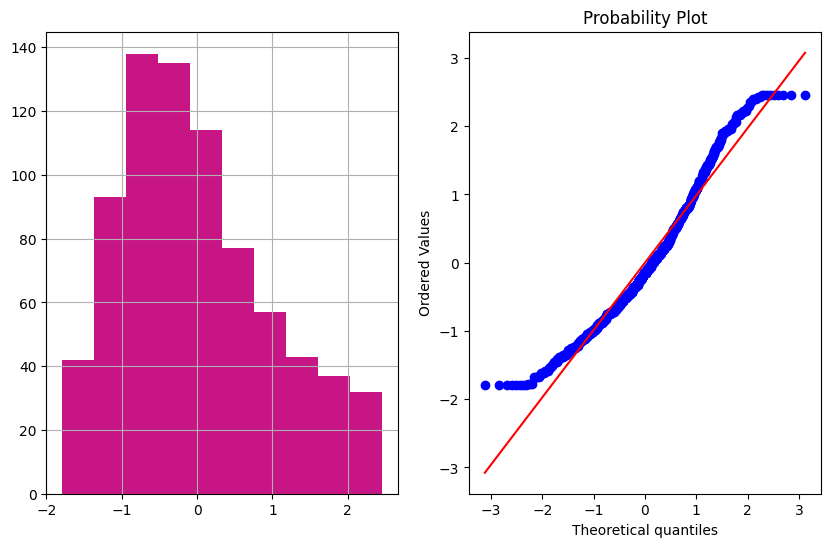

In [45]:
plot_data(df_X_scaled,'Glucose')

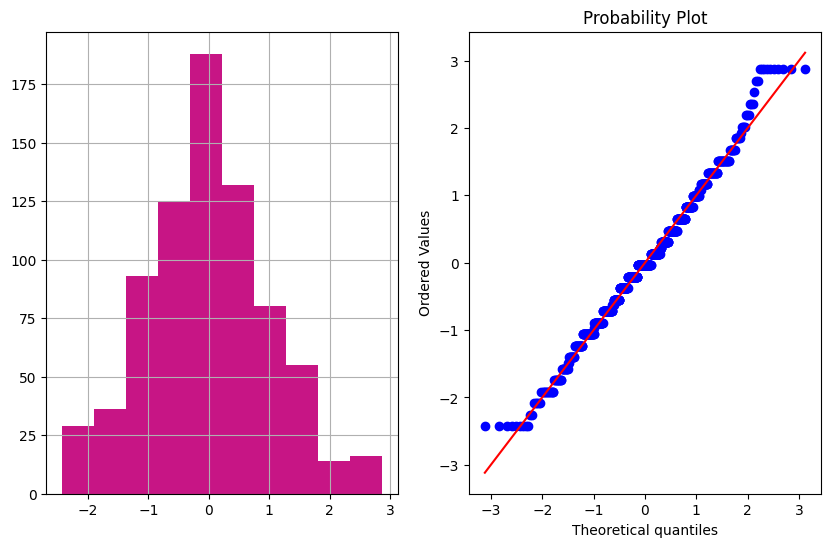

In [46]:
plot_data(df_X_scaled,'BloodPressure')

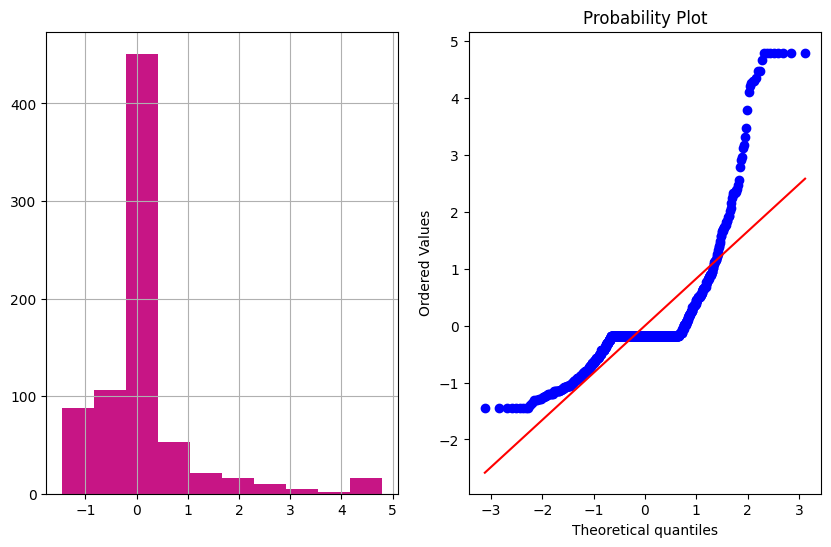

In [47]:
plot_data(df_X_scaled,'Insulin')

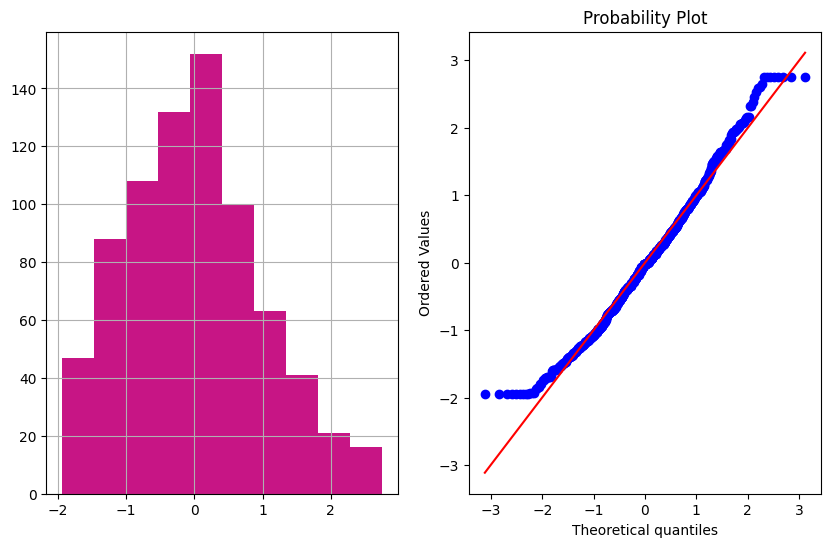

In [48]:
plot_data(df_X_scaled,'BMI')

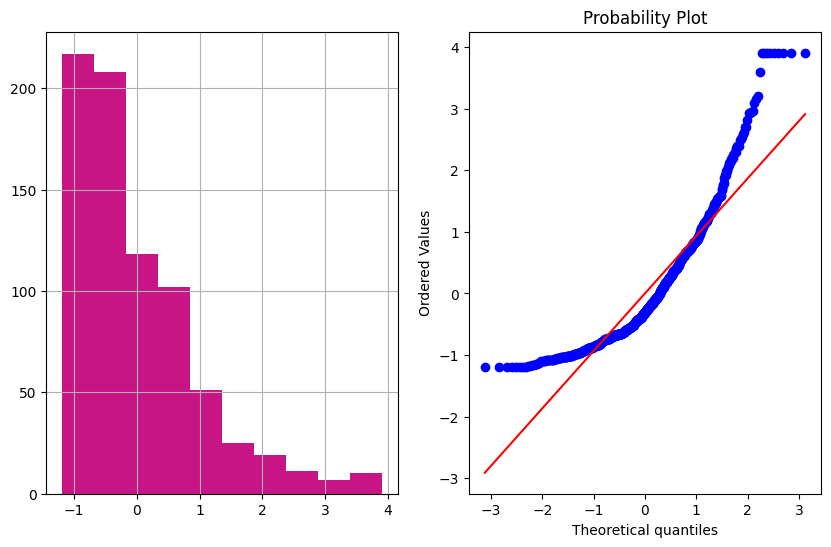

In [49]:
plot_data(df_X_scaled,'DiabetesPedigreeFunction')

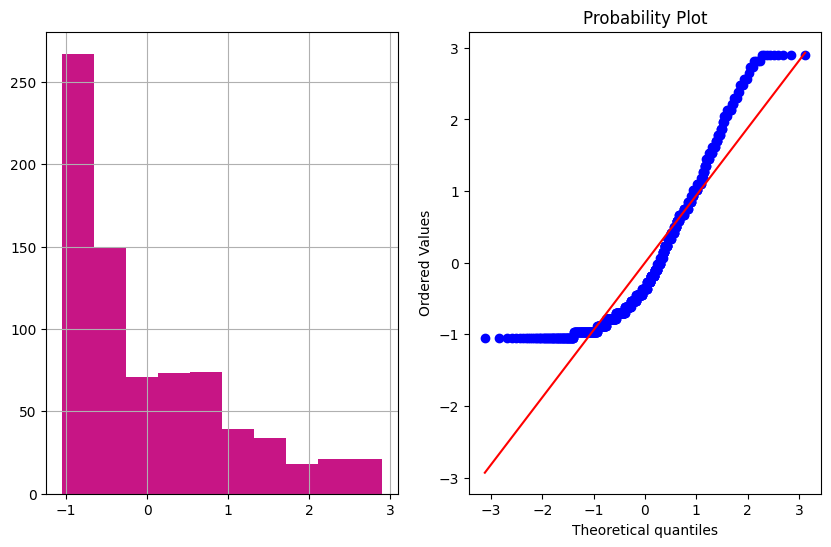

In [50]:
plot_data(df_X_scaled,'Age')

Generating scaled dataset

In [51]:
df_scaled = pd.concat([df_X_scaled, df_Y], axis=1)
df_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI,Insulin_Glucose,...,BMI.1,Age.1,Insulin.1,Glucose BMI,Glucose Age,Glucose Insulin,BMI Age,BMI Insulin,Age Insulin,Outcome
0,0.639947,0.869585,-0.035073,0.721377,-0.183459,0.179199,0.503867,1.443088,0.680424,0.034287,...,0.179199,1.443088,-0.183459,0.680424,1.580130,0.034287,1.384603,-0.136370,0.450398,1
1,-0.844885,-1.216525,-0.548137,-0.002142,-0.183459,-0.871453,-0.373314,-0.189533,-1.200427,-0.523406,...,-0.871453,-0.189533,-0.183459,-1.200427,-0.728212,-0.523406,-0.585136,-0.417810,-0.250113,0
2,1.233880,2.028534,-0.719158,-0.002142,-0.183459,-1.366760,0.646886,-0.103605,0.188745,0.344117,...,-1.366760,-0.103605,-0.183459,0.188745,0.832160,0.344117,-0.767050,-0.550489,-0.213244,1
3,-0.844885,-1.084073,-0.548137,-0.725661,-0.574702,-0.646313,-0.958101,-1.048806,-1.034037,-0.683385,...,-0.646313,-1.048806,-0.574702,-1.034037,-1.099291,-0.683385,-1.125122,-0.637687,-0.810817,0
4,-1.141852,0.505343,-2.429371,0.721377,0.359232,1.605083,3.908760,-0.017678,1.326771,0.354102,...,1.605083,-0.017678,0.359232,1.326771,0.185436,0.354102,0.791194,0.841691,0.242162,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,1.827813,-0.686719,0.306970,2.289002,0.510680,0.074133,-0.945388,2.560144,-0.463914,0.011625,...,0.074133,2.560144,0.510680,-0.463914,1.077769,0.011625,2.288878,0.417504,1.951703,0
764,-0.547919,0.008651,-0.206094,-0.243315,-0.183459,0.659496,-0.408274,-0.533242,0.345286,-0.195872,...,0.659496,-0.533242,-0.183459,0.345286,-0.408968,-0.195872,-0.195978,-0.007711,-0.397589,0
765,0.342981,-0.024462,-0.035073,-0.725661,-0.347529,-0.931490,-0.710202,-0.275460,-0.569824,-0.316121,...,-0.931490,-0.275460,-0.347529,-0.569824,-0.246197,-0.316121,-0.674021,-0.543445,-0.402013,0
766,-0.844885,0.141102,-1.061201,-0.002142,-0.183459,-0.346127,-0.379670,1.185306,-0.138140,-0.160463,...,-0.346127,1.185306,-0.183459,-0.138140,0.864132,-0.160463,0.773694,-0.277090,0.339791,1


Exporting transforemed dataset

In [52]:
df_scaled.to_csv('Diabetes-dataset_FT.csv', encoding='utf-8', index=False)